In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import rioxarray
import xcdat as xc
import DataAndCorr as DC

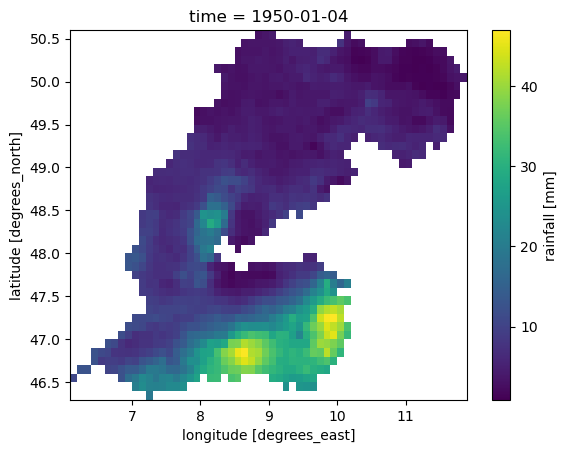

In [4]:
#import gridded data

P_grid = xr.open_dataset("Data/Rijn_up_prec.nc")
# P_test = P_grid.spatial.average('rr', axis=["X", "Y"])
# P_test = P_test.bounds.add_missing_bounds()

# plt.plot(P_test)
# P = P.bounds.add_missing_bounds()

T_grid = xr.open_dataset("Data/Rijn_up_temp.nc")
# T = T_grid.spatial.average('tg', axis=["X", "Y"])
# T = T.bounds.add_missing_bounds()

example = P_grid.isel(time = 3)
example['rr'].plot()

# print(P_grid['rr'])
# print(T_grid['tg'])


In [5]:
df = pd.read_pickle("Data/RijnData.pkl")
print(df)

                    P         T       0      1       2
time                                                  
1958-11-01   0.728547  3.953648  1450.0  106.0  1340.0
1958-11-02   7.457211  3.258784  1400.0  104.0  1300.0
1958-11-03  11.328147  6.560005  1410.0  102.0  1320.0
1958-11-04   4.229069  6.375669  1450.0  112.0  1370.0
1958-11-05   0.381288  5.198766  1570.0  106.0  1560.0
...               ...       ...     ...    ...     ...
2020-12-27   3.635903 -1.179034  1880.0  227.0  1530.0
2020-12-28   4.539444  1.064166  1680.0  189.0  1340.0
2020-12-29   1.646128  0.962366  1540.0  132.0  1260.0
2020-12-30   0.463582  0.216202  1490.0  142.0  1260.0
2020-12-31   2.714786 -0.272839  1440.0  125.0  1220.0

[22707 rows x 5 columns]


In [6]:
def snowcalculator2000(P, T):

    f = 2       #melt rate of 2 mm per day per deg C
    Tcrit = 1 

    Ss = 0      #Set snow storage to 0
    M = 0       #Set snowmelt to 0
    n = len(P)

    Ss, dSs, Ps, M  = np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)
    #Calculate for each day:
    for i,(P,T) in enumerate(zip(P,T)):
        if T < Tcrit:                   #If temperature is low enough, count precipitation as snowfall
            Ps[i] = P
        M[i] = min(f*max(T-Tcrit,0),Ss[i-1])    #Snowmelt is determined by available snow storage and temperature
        dSs[i] = Ps[i] - M[i]                    #Daily snow storage is snowfall minus snowmelt
        Ss[i] = Ss[i-1] + dSs[i]                   #new snow storage is old snow storage plus snowfall 
        # M[i] = min(f*max(T-Tcrit,0),Ss[i])    #Snowmelt is determined by available snow storage and temperature

    snow = pd.DataFrame(np.array([Ss, dSs, Ps, M]).T,columns=['Ss', 'dSs', 'Ps', 'M'])

    return snow['M']

In [7]:

def snowcalculator2000_grid(P, T, f=10, Tcrit=2):
    """
    Vectorized version of snowcalculator2000, applied to full grids at once.
    
    P, T : np.ndarray, shape (time, lat, lon)
    
    Returns
    -------
    M : np.ndarray, shape (time, lat, lon) — snowmelt
    """
    n_time, n_lat, n_lon = P.shape

    Ss  = np.zeros((n_time, n_lat, n_lon), dtype=np.float32)
    dSs = np.zeros_like(Ss)
    Ps  = np.zeros_like(Ss)
    M   = np.zeros_like(Ss)

    for i in range(n_time):
        # snowfall: precip counts as snow where T < Tcrit
        Ps[i] = np.where(T[i] < Tcrit, P[i], 0.0)

        # previous day's storage (day -1 wraps to zeros array, same as original)
        Ss_prev = Ss[i - 1]  # i=0 -> Ss[-1], which is still all zeros at this point

        # melt estimate, capped by previous storage
        M[i] = np.minimum(f * np.maximum(T[i] - Tcrit, 0.0), Ss_prev)

        # update storage
        dSs[i] = Ps[i] - M[i]
        Ss[i] = Ss_prev + dSs[i]

        if i%100 == 0:
            print(f"Progress: {100*i/n_time}%")
        
    return M,Ps,Ss


# --- Apply to your gridded data ---

# Force T_grid onto P_grid's exact coordinate grid
T_grid = T_grid.assign_coords(
    longitude=P_grid.longitude,
    latitude=P_grid.latitude,
)

ds = xr.Dataset({
    "P": P_grid["rr"],
    "T": T_grid["tg"],
})

P_vals = ds["P"].values.astype(np.float32)  # (time, lat, lon)
T_vals = ds["T"].values.astype(np.float32)

M_vals, Ps_vals, Sstorage_vals= snowcalculator2000_grid(P_vals, T_vals)

ds["M"] = (("time", "latitude", "longitude"), M_vals)
ds["Ps"] = (("time", "latitude", "longitude"), Ps_vals)
ds["Ss"] = (("time", "latitude", "longitude"), Sstorage_vals)

ds["P"] = (("time", "latitude", "longitude"), P_vals-Ps_vals)
# # carry over grid metadata
ds["longitude_bnds"] = P_grid["longitude_bnds"]
ds["latitude_bnds"] = P_grid["latitude_bnds"]
ds["spatial_ref"] = P_grid["spatial_ref"]




Progress: 0.0%
Progress: 0.3650434401693802%
Progress: 0.7300868803387603%
Progress: 1.0951303205081404%
Progress: 1.4601737606775207%
Progress: 1.8252172008469008%
Progress: 2.190260641016281%
Progress: 2.555304081185661%
Progress: 2.9203475213550414%
Progress: 3.2853909615244214%
Progress: 3.6504344016938015%
Progress: 4.015477841863182%
Progress: 4.380521282032562%
Progress: 4.745564722201942%
Progress: 5.110608162371322%
Progress: 5.475651602540703%
Progress: 5.840695042710083%
Progress: 6.205738482879463%
Progress: 6.570781923048843%
Progress: 6.935825363218223%
Progress: 7.300868803387603%
Progress: 7.665912243556983%
Progress: 8.030955683726363%
Progress: 8.395999123895743%
Progress: 8.761042564065123%
Progress: 9.126086004234503%
Progress: 9.491129444403883%
Progress: 9.856172884573263%
Progress: 10.221216324742644%
Progress: 10.586259764912025%
Progress: 10.951303205081405%
Progress: 11.316346645250785%
Progress: 11.681390085420166%
Progress: 12.046433525589546%
Progress: 12.4

In [8]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 27394, longitude: 58, latitude: 43, bnds: 2)
Coordinates:
  * time            (time) datetime64[ns] 219kB 1950-01-01 ... 2024-12-31
  * longitude       (longitude) float64 464B 6.15 6.25 6.35 ... 11.75 11.85
  * latitude        (latitude) float64 344B 46.35 46.45 46.55 ... 50.45 50.55
Dimensions without coordinates: bnds
Data variables:
    P               (time, latitude, longitude) float32 273MB nan nan ... nan
    T               (time, latitude, longitude) float32 273MB nan nan ... nan
    M               (time, latitude, longitude) float32 273MB nan nan ... nan
    Ps              (time, latitude, longitude) float32 273MB 0.0 0.0 ... 0.0
    Ss              (time, latitude, longitude) float32 273MB nan nan ... nan
    longitude_bnds  (longitude, bnds) float64 928B ...
    latitude_bnds   (latitude, bnds) float64 688B ...
    spatial_ref     int64 8B ...

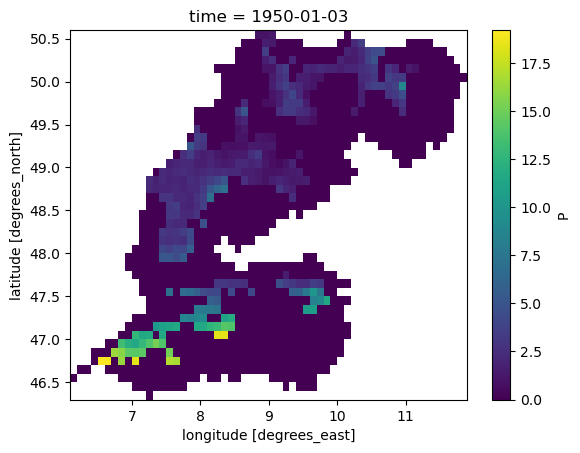

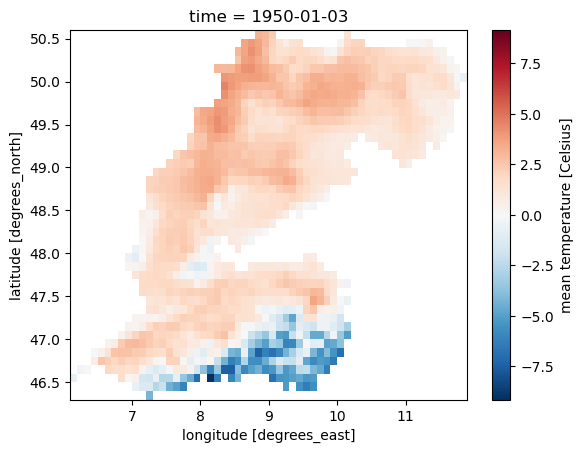

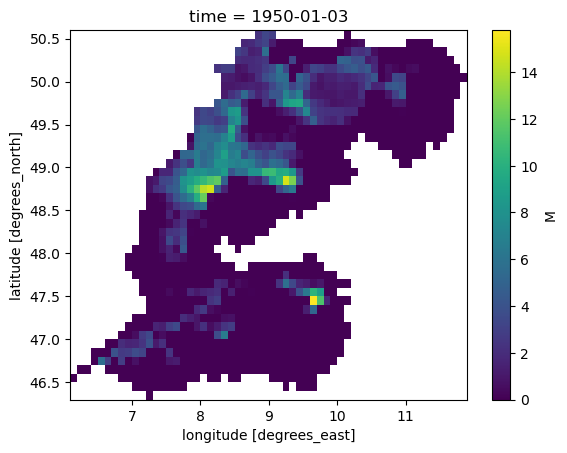

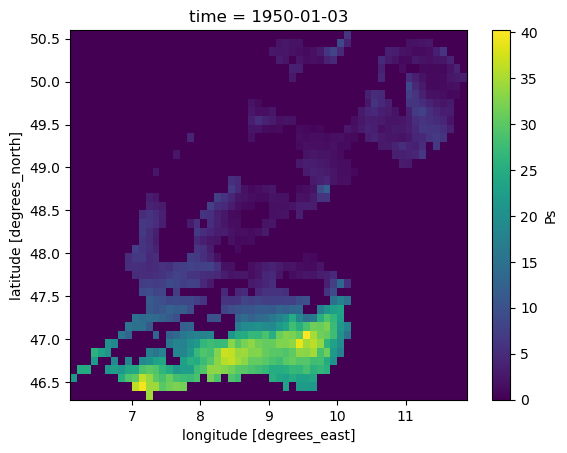

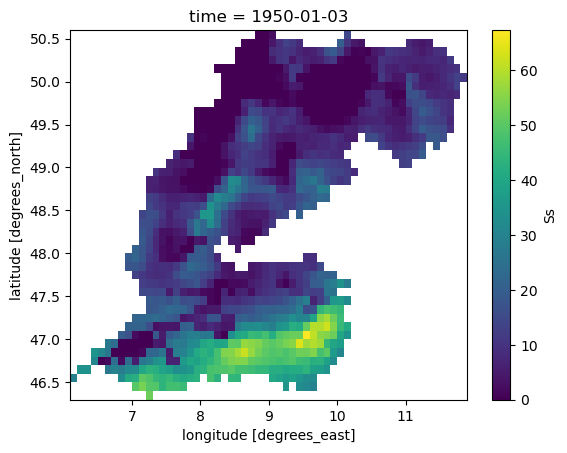

In [9]:
example1 = ds.isel(time=2)
for label in ["P","T","M","Ps","Ss"]:
    plt.figure()
    example1[label].plot()

In [10]:
ds_sum = ds.sum(dim=("latitude", "longitude"), skipna=True, keep_attrs=False)
ds_sum = ds_sum.drop_dims("bnds")

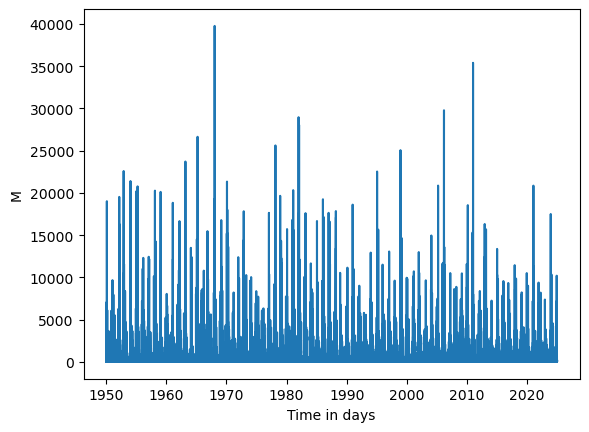

In [11]:
ds_sum["M"].plot()
# ds_sum["Ss"].plot()
# plt.xlim(10000,20000)

In [35]:
#Save to new pickle:
ds_df = ds_sum.to_dataframe()
ds_df.to_pickle("Data/Snowpickle.pkl")
ds_df['M'] = ds_df['M']/100

In [36]:
df_Q = DC.Qtomonth("Data/Discharges/Q_Lust.nc", "Q_Lust")
df_Q = df_Q.to_dataframe()
ds_df = pd.concat([df_Q, ds_df], axis=1,join="inner")

(1100.0, 1300.0)

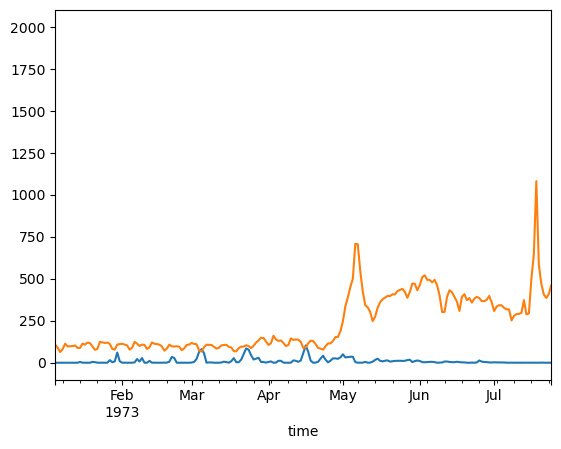

In [38]:

ds_df['M'].plot()
ds_df['Q_Lust'].plot()
plt.xlim(1100,1300)

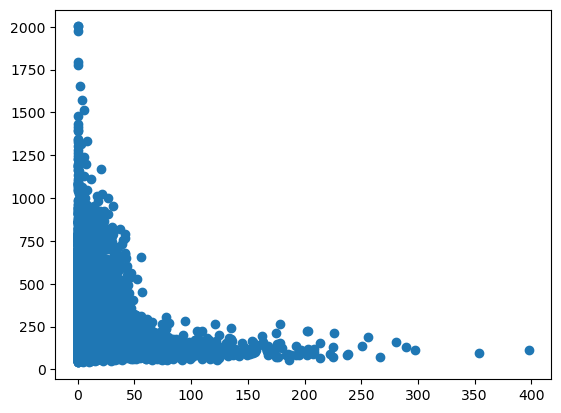

In [ ]:
plt.scatter(ds_df["M"].=, ds_df["Q_Lust"])